<a href="https://colab.research.google.com/github/apurvakumbhar/Deep_Learning/blob/main/DLExperiment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten 28x28 images to 784
X_train = X_train.reshape(60000, 784).astype('float32') / 255
X_test  = X_test.reshape(10000, 784).astype('float32') / 255

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print(X_train.shape, y_train.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
overfit_model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

overfit_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_overfit = overfit_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test, y_test)
)

In [ ]:
regularized_model = Sequential([
    Dense(512, activation='relu',
          kernel_regularizer=l2(0.001),
          input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation='relu',
          kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

regularized_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_regularized = regularized_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test, y_test)
)

In [ ]:
plt.plot(history_overfit.history['accuracy'], label='Overfit Train')
plt.plot(history_overfit.history['val_accuracy'], label='Overfit Val')

plt.plot(history_regularized.history['accuracy'], label='Regularized Train')
plt.plot(history_regularized.history['val_accuracy'], label='Regularized Val')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

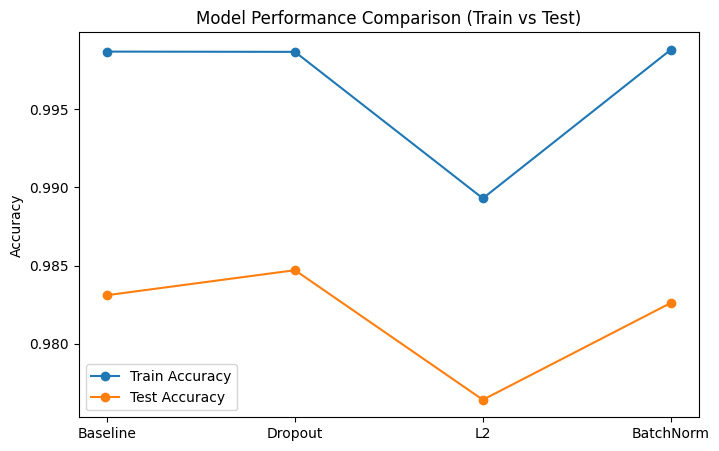

In [ ]:
models = ['Baseline', 'Dropout', 'L2', 'BatchNorm']
test_acc = [base_test_acc, drop_test_acc, l2_test_acc, bn_test_acc]

plt.figure(figsize=(7,5))
plt.bar(models, test_acc)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison on MNIST")
plt.ylim(0.9, 1.0)
plt.show()

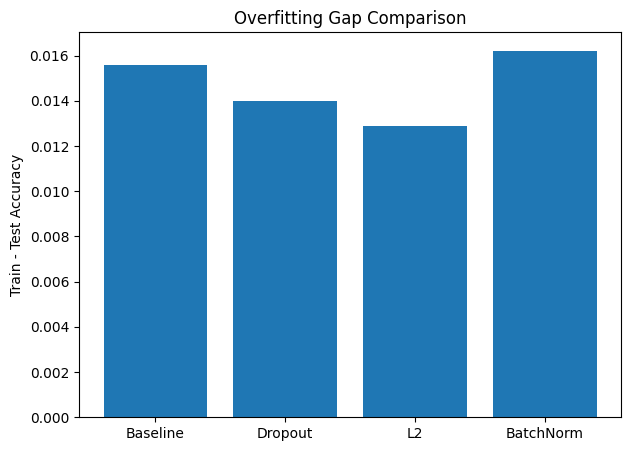